In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import  ColumnTransformer
from sklearn.linear_model import  LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import *
from preprocessing import IGRClipper
import joblib


Chargement des données

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
df.drop_duplicates(inplace=True)

Decoupage 80/20

In [5]:
x  = df[df.columns.difference(['Exam_Score'])]
y = df['Exam_Score']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Definir le Transformer pour les nombres numeriques

In [7]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class IGRClipper(BaseEstimator, TransformerMixin):

#       def fit(self, X, y=None):
#             #claculer du premier quartier
#             self.Q1 = np.percentile(X, 25, axis=0)

#             #calcul du troisieme quartie
#             self.Q3 = np.percentile(X, 75, axis=0)

#             #calcul de l'IQR
#             self.IQR = self.Q3 - self.Q1

#             #bornes inferieure et superieure
#             self.lower_bound_ = self.Q1 - 1.5 * self.IQR
#             self.upper_bound_ = self.Q3 + 1.5 * self.IQR

#             return self

#       def transform(self, X):
#             X = np.asarray(X)

#             #limiter les valeurs aux bornes IQR
#             X_clipped = np.clip(
#                   X,
#                   self.lower_bound_,
#                   self.upper_bound_
#             )
#             # _ Cette valeur a été apprise pendant fit().
#             return X_clipped


In [8]:
# def remove_outliers_iqr(df):

#     numeric_cols = df.select_dtypes(include='number').columns

#     # Créer un masque qui indique les lignes sans outliers
#     mask = pd.Series(True, index=df.index)

#     for col in numeric_cols:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)

#         IQR = Q3 - Q1

#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR

#         mask &= df[col].between(lower_bound, upper_bound)
        
#     df = df[mask].copy()
#     return df

In [9]:
# Suppression des outliers uniquement sur le train
#X_train_clean = remove_outliers_iqr(X_train)
#
## Garder les mêmes lignes dans y
#y_train_clean = y_train.loc[X_train_clean.index]

In [10]:
numeric_transformer = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='median')),
      ('iqr', IGRClipper()),
      ('scaler', StandardScaler())
])

In [11]:
categorical_transformer1 = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
categorical_transformer2 = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('OrdinalEncoder', OrdinalEncoder())
])

Creation deColumnTransfer class pour appliquer les transformation specifie dans le pipeline

In [13]:
features_preprocessor = ColumnTransformer(
      transformers=[
            ('numeric', numeric_transformer, ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores','Tutoring_Sessions', 'Physical_Activity']),
            ('categorical1', categorical_transformer1, ['Gender', 'School_Type', 'Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities', 'Peer_Influence']),
            ('categorical2', categorical_transformer2, ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income','Teacher_Quality','Parental_Education_Level', 'Distance_from_Home'])
      ],
      remainder='passthrough'
      )
#If there are columns that do not need transformation, you should set the remainder argument of the ColumnTransformer class to passthrough to ensure that these columns are retained. If not, they would be dropped by default)

In [14]:
Modelss  = {
     'LinearRegression' : (
                 LinearRegression()
           ),
           'RandomForestRegressor' : (
                 RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
           ),
           'SVR' : (
                 SVR()
           )
}
Models = {
      'LinearRegression' : (
            LinearRegression(),
            {
                  'regressor__fit_intercept' : [True, False],
                  'regressor__positive' : [True, False]
            }
      ),
      'RandomForestRegressor' : (
            RandomForestRegressor(n_estimators=200, max_depth=7, min_samples_split=2, random_state=42),
            {
                  'regressor__n_estimators': [100, 200, 300],
                  'regressor__max_depth': [None,3,4,5,6,7, 10, 20],
                  'regressor__min_samples_split': [2, 5, 10]
            }
      ),
      'SVR' : (
            SVR(),
            {
                  'regressor__C' : [0.1, 1],
                  'regressor__epsilon':[0.01, 0.1, 1],
                  'regressor__kernel' : ['linear', 'poly', 'rbf']
            }
      )
}

Dataframe to store accuracy, r2, mae, rmse

In [15]:
df_result = pd.DataFrame(columns=
    ['Models', 'R2', 'MAE', 'RMSE'])

df_results = pd.DataFrame(columns=
    ['Models', 'model_entrainer', 'R2', 'MAE', 'RMSE', 'CV_R2_Mean', 'CV_R2_STD', 'Residual_STD'])

predictions_before = {}
predictions_after = {}

In [16]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)


In [17]:
# Train a models
for model_name, (model, parameters) in Models.items():
      #create  pipeline to preprocess the feutures
      pipe = Pipeline(steps=[
      ('preprocessor', features_preprocessor),
      ('regressor', model)])

      #trian the model
      pipe.fit(X_train, y_train)

      #predict the Test
      predict = pipe.predict(X_test)
      predictions_before[model_name] = predict
      #append the result
      df_result.loc[len(df_result)] = {
            'Models': model_name,
            'R2': r2_score(y_test, predict),
            'MAE': mean_absolute_error(y_test, predict),
            'RMSE': root_mean_squared_error(y_test, predict)
      }

In [18]:
display(df_result.sort_values(by=['R2'], ascending=False))

,Models,R2,MAE,RMSE
2,SVR,0.755105,0.572769,1.860541
0,LinearRegression,0.686694,1.022747,2.104424
1,RandomForestRegressor,0.629677,1.296793,2.287912


In [19]:
# Train a models
for model_name, (model, parameters) in Models.items():
      #create  pipeline to preprocess the feutures
      pipe = Pipeline(steps=[
      ('preprocessor', features_preprocessor),
      ('regressor', model)])

      grid = GridSearchCV(estimator=pipe, param_grid=parameters, scoring='r2', cv=kf, n_jobs=-1, refit=True)

      #train the model
      grid.fit(X_train, y_train)
      p = grid.best_estimator_

      #predict the Test
      predict = p.predict(X_test)
      
      predictions_after[model_name] = predict

      #rediduals
      residuals = y_test - predict

      # Écart-type des résidus
      residual_std = np.std(residuals)
      
      #Moyene du R2 en validation croisé
      cv_r2_mean = grid.best_score_

      #Ecart-type du R2 en validation croisee
      cv_r2_std = grid.cv_results_['std_test_score'][grid.best_index_]


      # append results
      df_results.loc[len(df_results)] = {
            'Models': model_name,
            'model_entrainer' : p,
            'R2': r2_score(y_test, predict),
            'MAE': mean_absolute_error(y_test, predict),
            'RMSE': root_mean_squared_error(y_test, predict),
            'CV_R2_Mean' : cv_r2_mean,
            'CV_R2_STD': cv_r2_std,
            'Residual_STD' : residual_std
      }


display(df_results.sort_values(by=['R2'], ascending=False))

,Models,model_entrainer,R2,MAE,RMSE,CV_R2_Mean,CV_R2_STD,Residual_STD
2,SVR,"(ColumnTransformer(remainder='passthrough',\n ...",0.761647,0.534282,1.835519,0.702856,0.063654,1.831030
0,LinearRegression,"(ColumnTransformer(remainder='passthrough',\n ...",0.686694,1.022747,2.104424,0.644006,0.056228,2.104263
1,RandomForestRegressor,"(ColumnTransformer(remainder='passthrough',\n ...",0.666283,1.123142,2.171890,0.613504,0.050931,2.169646


In [20]:
df_comparison = df_result.merge(
    df_results,
    on='Models',
    suffixes=('_Before', '_After')
)

display(df_comparison)

,Models,R2_Before,MAE_Before,RMSE_Before,model_entrainer,R2_After,MAE_After,RMSE_After,CV_R2_Mean,CV_R2_STD,Residual_STD
0,LinearRegression,0.686694,1.022747,2.104424,"(ColumnTransformer(remainder='passthrough',\n ...",0.686694,1.022747,2.104424,0.644006,0.056228,2.104263
1,RandomForestRegressor,0.629677,1.296793,2.287912,"(ColumnTransformer(remainder='passthrough',\n ...",0.666283,1.123142,2.171890,0.613504,0.050931,2.169646
2,SVR,0.755105,0.572769,1.860541,"(ColumnTransformer(remainder='passthrough',\n ...",0.761647,0.534282,1.835519,0.702856,0.063654,1.831030


6. Visualisation des performances
- Comparaison des métriques

Text(0.5, 1.0, "Comparaison des métriques Avant et Apres l'optimisation")

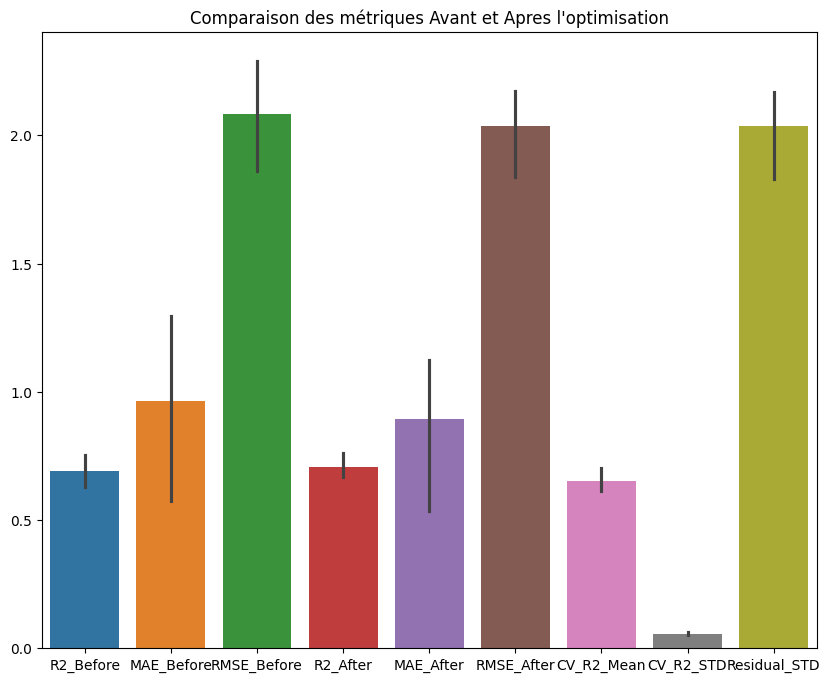

In [21]:
plt.figure(figsize=(10,8))
sns.barplot(df_comparison)
plt.title("Comparaison des métriques Avant et Apres l'optimisation")

## Prédictions vs valeurs réelles
- Prédictions vs valeurs réelles : les points proches de la diagonale indiquent une bonne correspondance entre les valeurs prédites et les valeurs réelles.


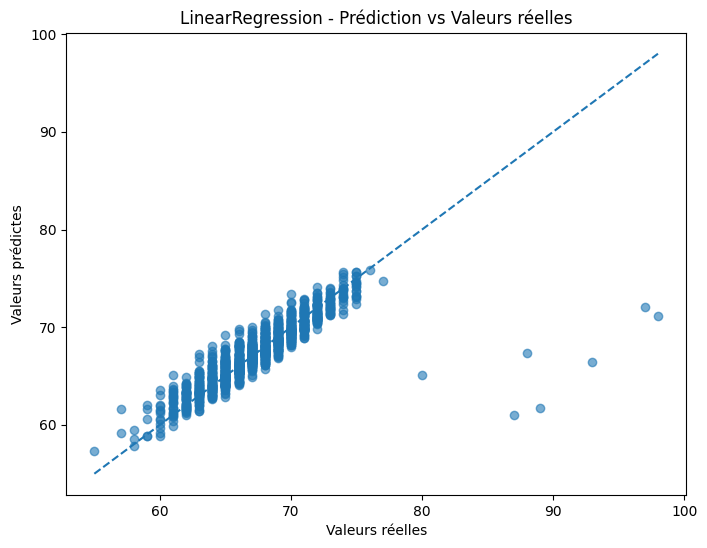

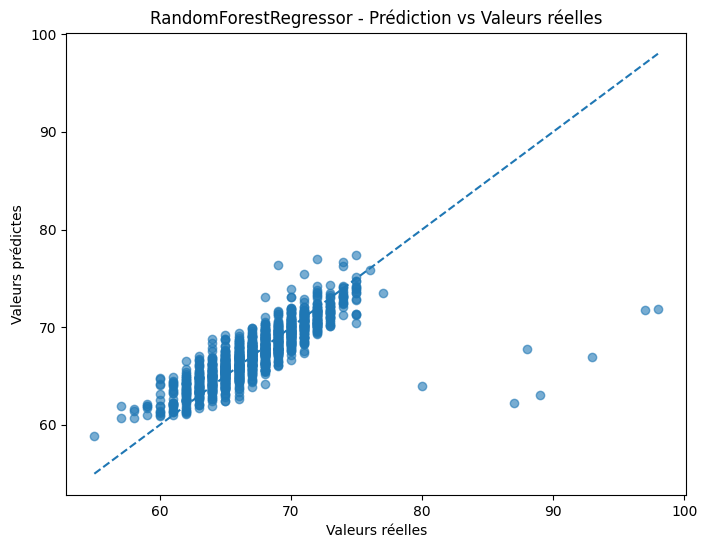

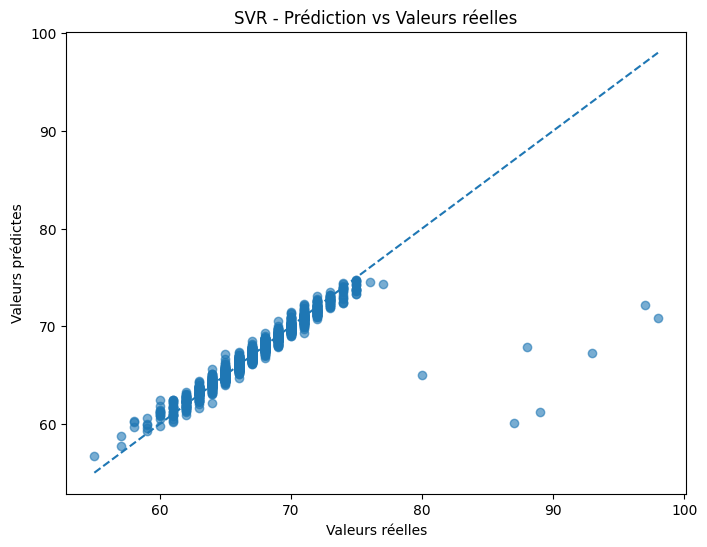

In [22]:
for model_name, predict in predictions_before.items():
      plt.figure(figsize=(8,6))

      plt.scatter(y_test, predict, alpha=0.6)
      plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--',
        label="Prédiction parfaite"
    )

      plt.xlabel("Valeurs réelles")
      plt.ylabel("Valeurs prédictes")
      plt.title(f'{model_name} - Prédiction vs Valeurs réelles')
      plt.show()

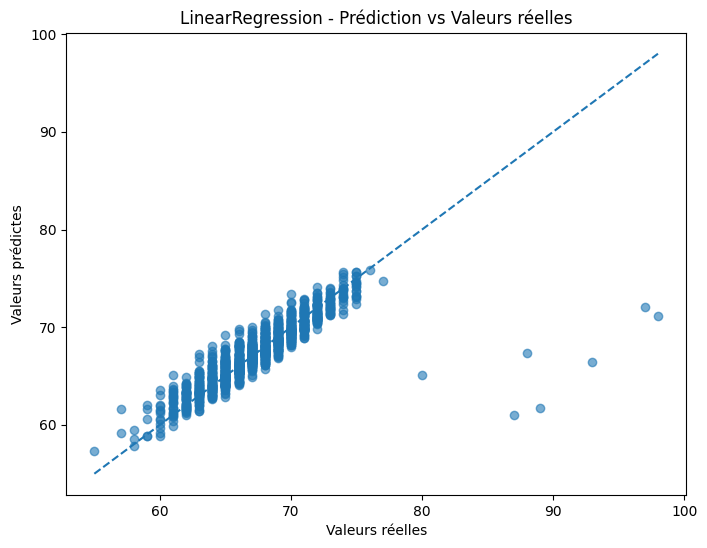

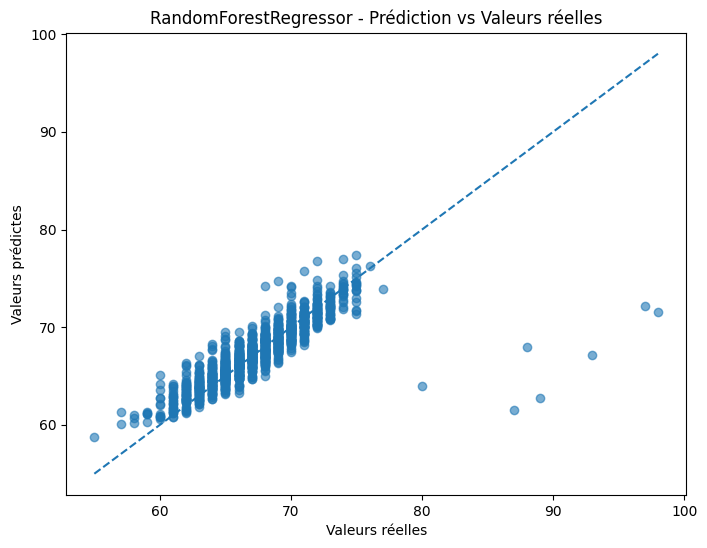

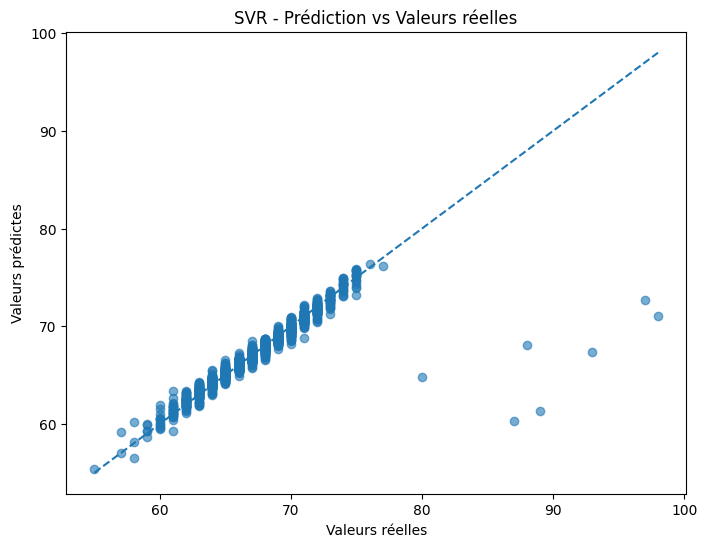

In [23]:
for model_name, predict in predictions_after.items():
      plt.figure(figsize=(8,6))

      plt.scatter(y_test, predict, alpha=0.6)
      plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--',
        label="Prédiction parfaite"

    )

      plt.xlabel("Valeurs réelles")
      plt.ylabel("Valeurs prédictes")
      plt.title(f'{model_name} - Prédiction vs Valeurs réelles')
      plt.show()

## Maintenant les résidus
- Distribution des résidus : une distribution centrée autour de zéro indique que les erreurs de prédiction sont globalement équilibrées.
- une dispersion aléatoire des résidus autour de zéro est généralement souhaitable. Une structure ou une forme particulière peut indiquer que le modèle ne capture pas complètement certaines relations présentes dans les données.

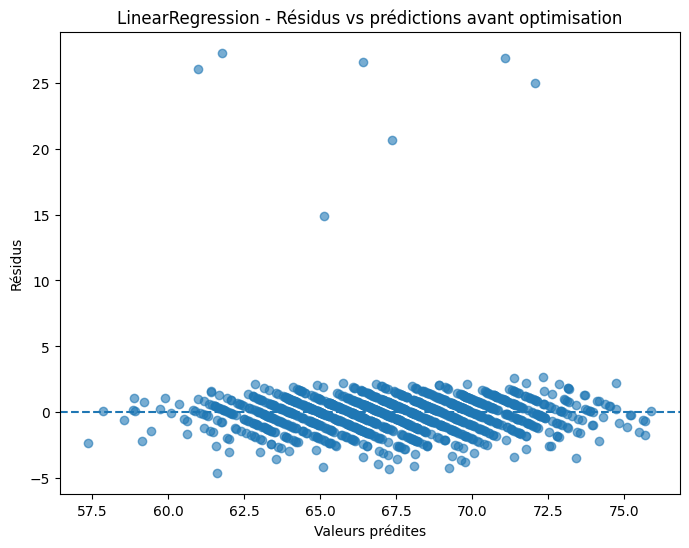

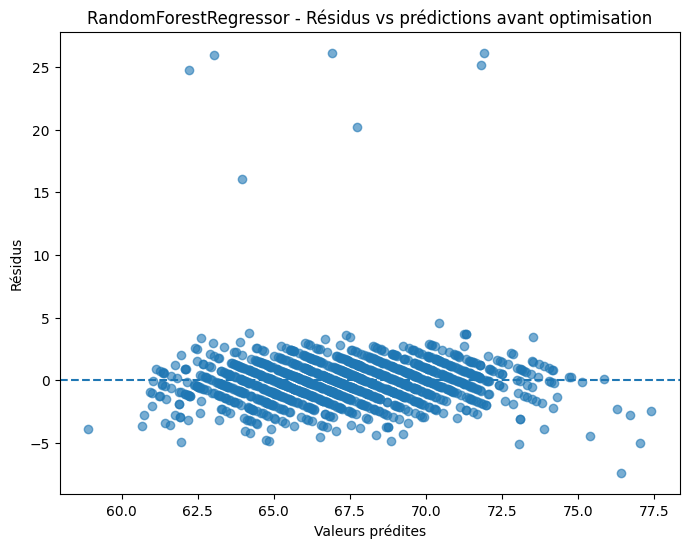

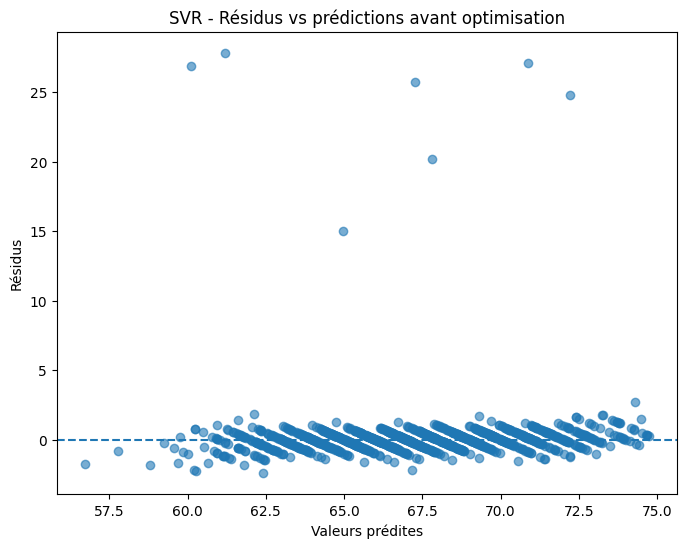

In [24]:
for model_name, predict in predictions_before.items():
      residuals = y_test - predict
      plt.figure(figsize=(8, 6))

      plt.scatter(predict, residuals, alpha=0.6)

      plt.axhline(0, linestyle='--')

      plt.xlabel("Valeurs prédites")
      plt.ylabel("Résidus")
      plt.title(f"{model_name} - Résidus vs prédictions avant optimisation")

      plt.show()

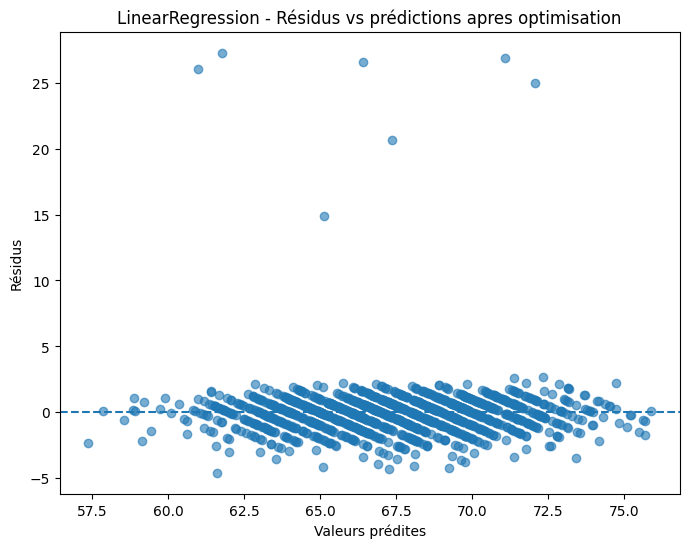

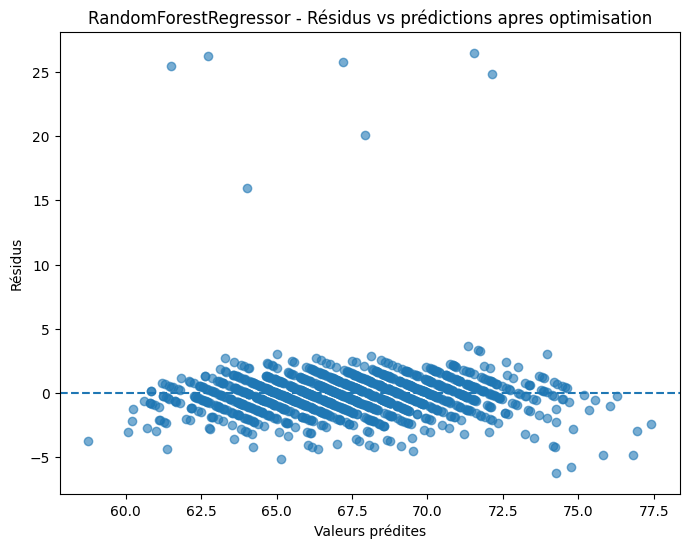

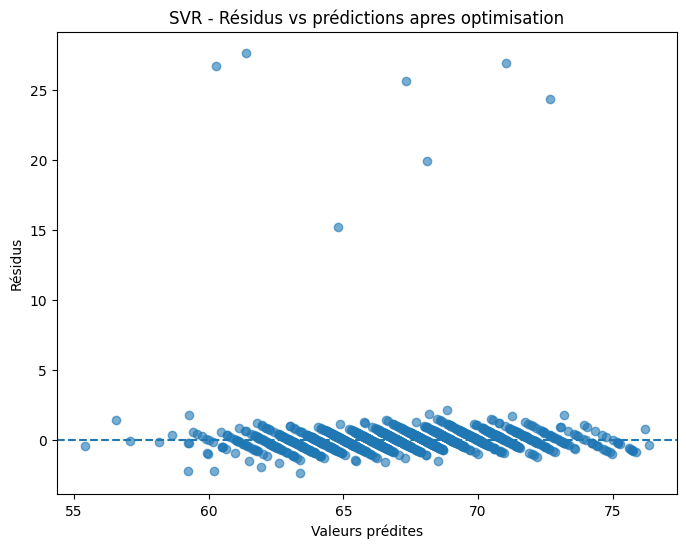

In [25]:
for model_name, predict in predictions_after.items():
      residuals = y_test - predict
      plt.figure(figsize=(8, 6))

      plt.scatter(predict, residuals, alpha=0.6)

      plt.axhline(0, linestyle='--')

      plt.xlabel("Valeurs prédites")
      plt.ylabel("Résidus")
      plt.title(f"{model_name} - Résidus vs prédictions apres optimisation")

      plt.show()

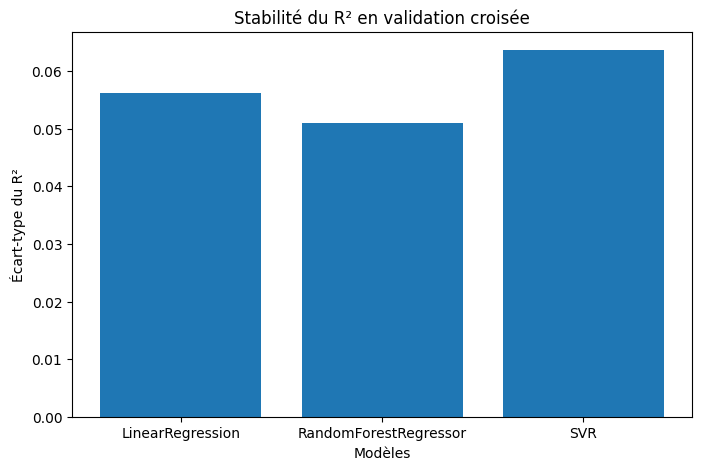

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_results['Models'],
    df_results['CV_R2_STD']
)

plt.xlabel("Modèles")
plt.ylabel("Écart-type du R²")
plt.title("Stabilité du R² en validation croisée")

plt.show()

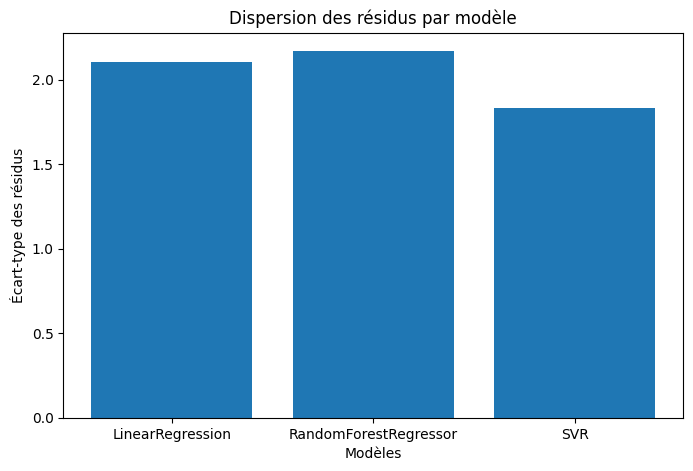

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_results['Models'],
    df_results['Residual_STD']
)

plt.xlabel("Modèles")
plt.ylabel("Écart-type des résidus")
plt.title("Dispersion des résidus par modèle")

plt.show()

- Le modèle final a été retenu en considérant simultanément ses performances sur le jeu de test et sa stabilité en validation croisée. Le R², la MAE et la RMSE permettent d'évaluer la qualité des prédictions, tandis que l'écart-type du R² entre les folds permet d'évaluer la stabilité du modèle. L'écart-type des résidus complète cette analyse en mesurant la dispersion des erreurs sur le jeu de test.

### Test et Téléchargement du Modèle

In [28]:
best_model = df_results.iloc[0]

joblib.dump(best_model.model_entrainer, 'meilleur_model.joblib')

['meilleur_model.joblib']